In [10]:
!pip install tabulate

/bin/bash: pip: command not found


In [1]:
import numpy as np
import pandas as pd

import japanize_matplotlib
import matplotlib.pyplot as plt

## 演習問題4.1

In [2]:
# 表4.5の作成
df_45 = pd.DataFrame(
    {
        "year": [1984, 1985, 1986, 1987, 1988],
        "四半期_1": [1, 27, 43, 88, 110],
        "四半期_2": [6, 39, 51, 97, 113],
        "四半期_3": [16, 31, 63, 91, 149],
        "四半期_4": [23, 30, 70, 104, 159],
    }
)

## (a)

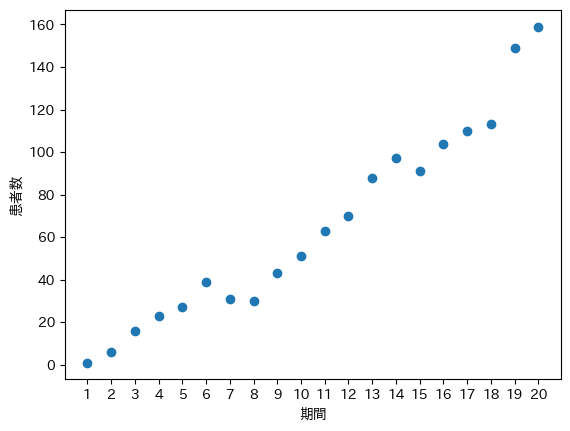

In [3]:
array_45 = df_45.drop(["year"], axis=1).values.reshape(-1)

plt.scatter(list(range(1, len(array_45) + 1)), array_45)

plt.xlabel("期間")  # x軸ラベル
plt.ylabel("患者数")  # y軸ラベル

plt.xticks(range(1, len(array_45) + 1))

plt.savefig("4_1_a.png")

plt.show()

## (b)

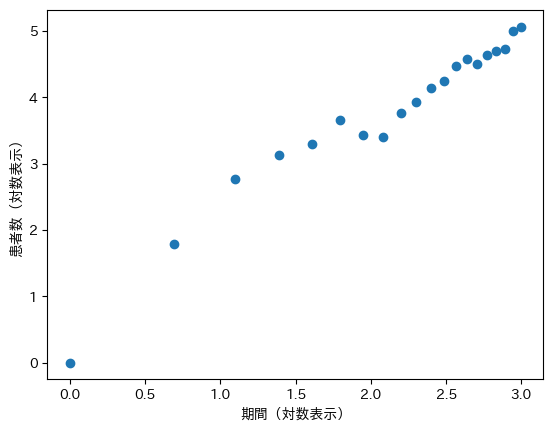

In [4]:
plt.scatter(np.log(list(range(1, len(array_45) + 1))), np.log(array_45))

plt.xlabel("期間（対数表示）")  # x軸ラベル
plt.ylabel("患者数（対数表示）")  # y軸ラベル
plt.savefig("4_1_b.png")
plt.show()

## (c)

In [5]:
X = np.stack(
    (np.ones(len(array_45)), np.log(list(range(1, len(array_45) + 1)))), axis=1
)

y = array_45.copy()

# パラメータの初期値
beta = np.ones(X.shape[1])
n_iters = 10

list_beta = []
for t in range(n_iters):
    eta_t = X @ beta
    lambda_t = np.exp(eta_t)
    z_t = eta_t + (y - lambda_t) / lambda_t
    W_t = np.diag(lambda_t)
    beta = np.linalg.inv((X.T) @ W_t @ X) @ (X.T) @ W_t @ z_t
    list_beta.append(beta)

## (d)

In [7]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [8]:
data = pd.DataFrame(np.stack((X[:, 1], y), axis=1), columns=["x", "y"])
model = smf.glm(formula="y ~ x", data=data, family=sm.families.Poisson())
result = model.fit()

In [9]:
print(
    pd.DataFrame(
        result.params.values.reshape(1, 2), columns=["beta_0", "beta_1"]
    ).to_markdown()
)

ImportError: Missing optional dependency 'tabulate'.  Use pip or conda to install tabulate.

# 演習問題4.2

In [1]:
import pandas as pd
import numpy as np
import japanize_matplotlib
import matplotlib.pyplot as plt

In [2]:

# データ
x = [65, 156, 100, 134, 16, 108, 121, 4, 39,
     143, 56, 26, 22, 1, 1, 5, 65]

y = [3.36, 2.88, 3.63, 3.41, 3.78, 4.02, 4.00, 4.23, 3.73,
     3.85, 3.97, 4.51, 4.54, 5.00, 5.00, 4.72, 5.00]

# DataFrame 作成
df = pd.DataFrame({
    "x": x,
    "y": y
})

## (a)

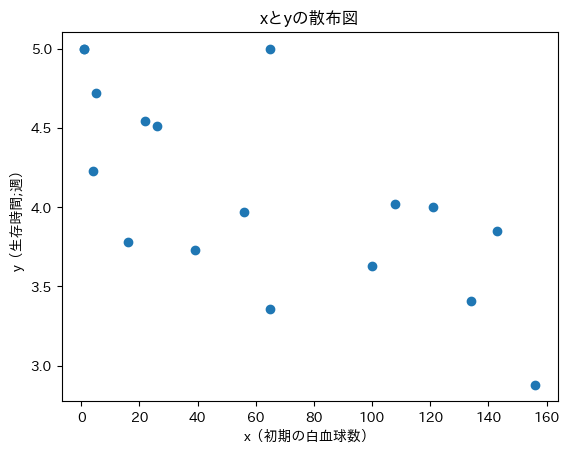

In [4]:
plt.title("xとyの散布図")
plt.scatter(df["x"], df["y"])
plt.xlabel("x（初期の白血球数）")
plt.ylabel("y（生存時間;週）")
plt.savefig("4_2_a.png")
plt.show()

## (c)

In [5]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [6]:
model_exp = smf.glm(
    formula="y ~ x",
    data=df,
    family=sm.families.Gamma(link=sm.families.links.log())
)
results_exp = model_exp.fit()

# model_exp = smf.glm(
#     formula="log_y ~ x",
#     data=df,
#     family=sm.families.Gamma(link=sm.families.links.identity())
# )
# results_exp = model_exp.fit()

/Users/shinodzukahiroshiichirou/Desktop/programing/introduction-to-glm/.venv/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


In [7]:
results_exp.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      y   No. Observations:                   17
Model:                            GLM   Df Residuals:                       15
Model Family:                   Gamma   Df Model:                            1
Link Function:                    log   Scale:                        0.013468
Method:                          IRLS   Log-Likelihood:                -10.347
Date:                Tue, 06 Jan 2026   Deviance:                      0.20315
Time:                        00:47:37   Pearson chi2:                    0.202
No. Iterations:                     5   Pseudo R-squ. (CS):             0.5458
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.5278      0.044     35.013      0.000       1.442       1.613
x             -0.0020      0.001     -3.694      0.000      -0.003      -0.001
==============================================================================
"""

## (d)

In [8]:
df["predicted"] = np.exp(results_exp.params["x"] * df["x"] + results_exp.params["Intercept"])
df["r"] = (df["y"] - df["predicted"]) / df["predicted"]

In [9]:
df

,x,y,log_y,predicted,r
0,65,3.36,1.211941,4.053903,-0.171169
1,156,2.88,1.057790,3.388056,-0.149955
2,100,3.63,1.289233,3.783581,-0.040591
3,134,3.41,1.226712,3.538254,-0.036248
4,16,3.78,1.329724,4.465106,-0.153436
5,108,4.02,1.391282,3.724369,0.079377
6,121,4.00,1.386294,3.630119,0.101892
7,4,4.23,1.442202,4.572012,-0.074806
8,39,3.73,1.316408,4.267141,-0.125879
9,143,3.85,1.348073,3.476021,0.107588


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   17
Model:                            GLM   Df Residuals:                       15
Model Family:                   Gamma   Df Model:                            1
Link Function:                    Log   Scale:                        0.013468
Method:                          IRLS   Log-Likelihood:                -10.347
Date:                Tue, 06 Jan 2026   Deviance:                      0.20315
Time:                        00:46:49   Pearson chi2:                    0.202
No. Iterations:                     5   Pseudo R-squ. (CS):             0.5458
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5278      0.044     35.013      0.0

/var/folders/g4/gx0098gn4072x6j58_7tw_8c0000gn/T/ipykernel_5729/402577194.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = np.exp(results.params[0] + results.params[1] * x_range)


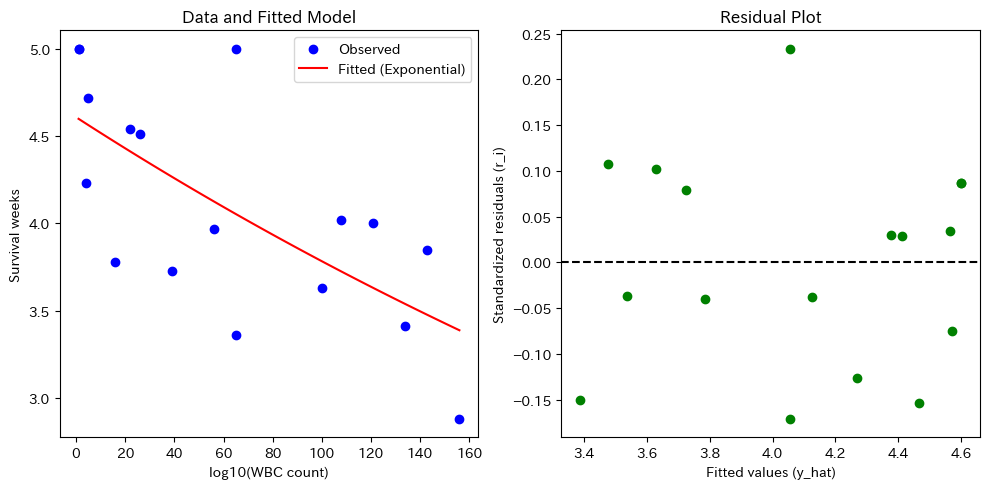

In [20]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. データの入力
# x: log10(白血球数), y: 生存週数
data = {
    'x': [65, 156, 100, 134, 16, 108, 121, 4, 39, 143, 56, 26, 22, 1, 1, 5, 65],
    'y': [3.36, 2.88, 3.63, 3.41, 3.78, 4.02, 4.00, 4.23, 3.73, 3.85, 3.97, 4.51, 4.54, 5.00, 5.00, 4.72, 5.00]
}
df = pd.DataFrame(data)

# 2. モデルの構築 (b, c)
# E(Y) = exp(beta1 + beta2 * x) -> Log Link
X = sm.add_constant(df['x'])  # 切片項の追加
# 指数分布はガンマ分布の特殊例として扱う
model = sm.GLM(df['y'], X, family=sm.families.Gamma(link=sm.families.links.Log()))
results = model.fit()

# 3. 結果の出力
print(results.summary())

# 4. 適合値と標準化残差の計算 (d)
df['y_hat'] = results.predict(X)
df['std_residual'] = (df['y'] - df['y_hat']) / df['y_hat']

print("\n--- 適合値と標準化残差 (一部) ---")
print(df[['x', 'y', 'y_hat', 'std_residual']])

# 5. 可視化
plt.figure(figsize=(10, 5))

# プロット1: データと適合曲線
plt.subplot(1, 2, 1)
plt.scatter(df['x'], df['y'], color='blue', label='Observed')
x_range = np.linspace(df['x'].min(), df['x'].max(), 100)
y_pred = np.exp(results.params[0] + results.params[1] * x_range)
plt.plot(x_range, y_pred, color='red', label='Fitted (Exponential)')
plt.xlabel('log10(WBC count)')
plt.ylabel('Survival weeks')
plt.title('Data and Fitted Model')
plt.legend()

# プロット2: 標準化残差の確認
plt.subplot(1, 2, 2)
plt.scatter(df['y_hat'], df['std_residual'], color='green')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Fitted values (y_hat)')
plt.ylabel('Standardized residuals (r_i)')
plt.title('Residual Plot')

plt.tight_layout()
plt.show()